<a href="https://colab.research.google.com/github/Apolinar1o/IcMachinaLearning/blob/main/pysus_limed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install PySUS
!pip install geopandas
!pip install geobr
!pip install numpy
!pip install openpyxl
!pip install pyarrow



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 1.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 835.4 kB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 385.7/385.7 kB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.7/118.7 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 247.7/247.7 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.5/63.5 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.4/300.4 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 338.0/338.0 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 67.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 72.1 MB/s eta 0:00:00
  Attempting uninstall: shapely
    Found existing installation: shapely 2.1.2
    Uninstalling shapely-2.1.2:
      Successfully uninstalled shapely-2.1.2
  Attempting uninstall: lxml
    Found existing installation: lxml 6.0.2
    Uninstalling lxml-6.0.2:
      Successfully uninstalled lxml-6.0.2
  Attempting uninstall: geopandas
    Found existing installation: geopandas 1.1.3
    Uninstalling geopandas-1.1.3:
      Successfully uninstalled geopandas-1.1.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
blobfile 3.2.0 requires urllib3>=2, but you have urllib3 1.26.20 which is incompatible.
tobler 0.13.0 requires tqdm>=4.67, but 

In [ ]:
import pandas as pd
import geobr
import matplotlib.pyplot as plt
from pysus import SIM

##codigo para somente 1 estado do BRASil

sim = SIM().load()


arquivos = sim.get_files("CID10", uf="RJ", year="2022")

dados = sim.download(arquivos)
df = dados.to_dataframe()

coluna_codigos = df['CODMUNRES']
df['cod_cidade'] = coluna_codigos.astype(str)
df['cod_cidade'] = df['cod_cidade'].str.slice(0, 6)

contagem = df['cod_cidade'].value_counts()

mortes_cidade = contagem.reset_index()
mortes_cidade.columns = ['cod_cidade', 'qtd_mortes']

mapa = geobr.read_municipality(code_muni="RJ", year=2022)
texto_codigos = mapa['code_muni'].astype(str)
mapa['cod_6'] = texto_codigos.str.slice(0, 6)

mapa_final = mapa.merge(mortes_cidade, left_on="cod_6", right_on="cod_cidade", how="left")
mapa_final['qtd_mortes'] = mapa_final['qtd_mortes'].fillna(0)


mapa_final.plot(column='qtd_mortes',
                cmap='Reds',
                legend=True,
                figsize=(12, 8),
                edgecolor='black',
                linewidth=0.1)

plt.axis('off')
plt.show()

11928191it [00:00, 7658114070.73it/s]


KeyboardInterrupt: 

In [ ]:
import pandas as pd
import geobr
import matplotlib.pyplot as plt
from pysus import SIM

##codigo feito para mais estados

sim = SIM().load()


arquivos = sim.get_files("CID10", uf="RJ"  ,year="2022")

dados = sim.download(arquivos)
print("0000000000000000000000")
temporario = []
for item in dados:
    df = item.to_dataframe()
    temporario.append(df)
df_brasil = pd.concat(temporario, ignore_index=True)

print("1111111111111111111111111111111")

coluna_codigos = df_brasil['CODMUNRES']
df_brasil['cod_cidade'] = coluna_codigos.astype(str)
df_brasil['cod_cidade'] = df_brasil['cod_cidade'].str.slice(0, 6)
print("2222222222222222222222")

contagem = df_brasil['cod_cidade'].value_counts()

print("33333333333333333333333333")
mortes_cidade = contagem.reset_index()

mortes_cidade.columns = ['cod_cidade', 'qtd_mortes']
print("44444444444444444444444444444")


rj = geobr.read_municipality(code_muni="all",year=2022)

mapa = pd.concat([  rj], ignore_index=True)
print("5555555555555555555555")

texto_codigos = mapa['code_muni'].astype(str)
mapa['cod_6'] = texto_codigos.str.slice(0, 6)

mapa_final = mapa.merge(mortes_cidade, left_on="cod_6", right_on="cod_cidade", how="left")
mapa_final['qtd_mortes'] = mapa_final['qtd_mortes'].fillna(0)
print("66666666666666666666666666666666")
#%%
mapa_final.plot(column='qtd_mortes',
                cmap='Reds',
                legend=True,
                figsize=(12, 8),
                edgecolor='black',
                linewidth=0.1)
print("777777777777777777777777777777")
plt.savefig('mapa_mortalidade_rj.png', dpi=300, bbox_inches='tight')


DORS2022.dbc:   4%|▍         | 336k/8.08M [00:02<00:22, 338kB/s]

KeyboardInterrupt: 

In [ ]:

import pandas as pd
import numpy as np
from pysus import SIM
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

sim = SIM().load()
rj = sim.get_files("CID10", uf="RJ", year=2022)
download = sim.download(rj)
dataf_rj = download.to_dataframe()

dataf_rj['target'] = (dataf_rj['CAUSABAS'] == 'I219').astype(int)

cols_x = ["IDADE", "RACACOR", "SEXO"]
df_modelo = dataf_rj[cols_x + ['target']].copy()


for col in cols_x:
    df_modelo[col] = pd.to_numeric(df_modelo[col], errors='coerce')

df_modelo = df_modelo.dropna()

df_modelo['IDADE'] = df_modelo['IDADE'].apply(lambda x: x - 400 if x >= 400 else 0)


X = df_modelo[cols_x]
y = df_modelo['target']


x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2)


scaler = StandardScaler()
x_train_st = scaler.fit_transform(x_train)
x_test_st = scaler.transform(x_test)


model_xgb = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=15,
    random_state=2
)
model_xgb.fit(x_train_st, y_train)


y_pred = model_xgb.predict(x_test_st)

importancias = pd.Series(model_xgb.feature_importances_, index=X.columns)
importancias.nlargest(3).plot(kind='barh', color='skyblue')
plt.title('O que mais importa para prever Infarto?')
plt.xlabel('Importância Relativa')
plt.show()

print(f"--- Resultado da IA (UERJ/FAPERJ) ---")
print(f"Acurácia: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nRelatório de Performance:")
print(classification_report(y_test, y_pred))

TypeError: 'module' object is not callable

DORJ2020.parquet: : 11.9MB [00:25, 465kB/s] 


--- RESULTADO DA PESQUISA (UERJ/FAPERJ) ---
Acurácia Geral: 50.16%

Relatório focado em Mortes Evitáveis (Classe 1):
              precision    recall  f1-score   support

           0       0.86      0.46      0.60    151237
           1       0.23      0.69      0.35     35700

    accuracy                           0.50    186937
   macro avg       0.55      0.57      0.47    186937
weighted avg       0.74      0.50      0.55    186937



<Figure size 1000x600 with 0 Axes>

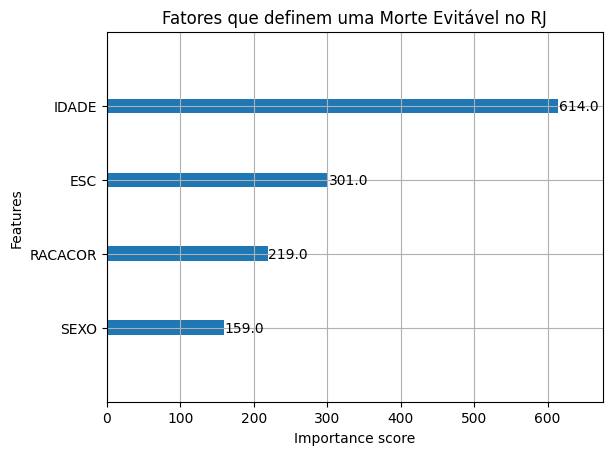

In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
from pysus import SIM
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt

# 1. CARREGAMENTO DOS DADOS (SIM/RJ 2022)
sim = SIM().load()
arquivos = sim.get_files("CID10", uf="RJ", year=["2022", "2021", "2020", "2019"])
download = sim.download(arquivos)

temporario = []
for item in download:
    df_bruto_init = item.to_dataframe()
    temporario.append(df_bruto_init)
df_bruto = pd.concat(temporario, ignore_index=True)



cids_clinica_familia = [
    'E10', 'E11', 'E12', 'E13', 'E14',
    'I10', 'I11', 'I12', 'I13', 'I15',
    'I6',
    'I50',
    'J40', 'J41', 'J42', 'J43', 'J44', 'J45', 'J46', 'J47',
    'A0'
]


df_bruto['target_evitavel'] = df_bruto['CAUSABAS'].str.startswith(tuple(cids_clinica_familia)).astype(int)


colunas_ia = ['IDADE', 'SEXO', 'RACACOR', 'ESC']
df_ia = df_bruto[colunas_ia + ['target_evitavel']].copy()


for col in colunas_ia:
    df_ia[col] = pd.to_numeric(df_ia[col], errors='coerce')

df_ia = df_ia.dropna()


df_ia['IDADE'] = df_ia['IDADE'].apply(lambda x: x - 400 if x >= 400 else 0)

X = df_ia[colunas_ia]
y = df_ia['target_evitavel']


x_treino, x_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.3, random_state=2)


peso_ajuste = (y_treino == 0).sum() / (y_treino == 1).sum()

modelo_faperj = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=peso_ajuste,
    random_state=2
)

modelo_faperj.fit(x_treino, y_treino)

# 5. AVALIAÇÃO DO IMPACTO
y_pred = modelo_faperj.predict(x_teste)

print("--- RESULTADO DA PESQUISA (UERJ/FAPERJ) ---")
print(f"Acurácia Geral: {accuracy_score(y_teste, y_pred)*100:.2f}%")
print("\nRelatório focado em Mortes Evitáveis (Classe 1):")
print(classification_report(y_teste, y_pred))



# Mostra quais colunas (Idade, Escolaridade, etc) mais ajudaram o XGBoost
plt.figure(figsize=(10, 6))
xgb.plot_importance(modelo_faperj, importance_type='weight', max_num_features=10)
plt.title('Fatores que definem uma Morte Evitável no RJ')
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
from pysus import SIM
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# --- 1. CONFIGURAÇÕES INICIAIS ---
UF_FOCO = 'RJ'
COD_UF_INICIO = '33'
ANOS_ESTUDO = ["2015", "2016", "2017", "2018", "2019"]

# --- 2. CARREGAMENTO DOS ÓBITOS (SIM/DATASUS) ---
# Seguindo a lógica da Etapa 2 do R: óbitos de 2015 a 2019
print("A carregar dados do SIM via PySUS...")
sim = SIM().load()
arquivos = sim.get_files("CID10", uf=UF_FOCO, year=ANOS_ESTUDO)
download = sim.download(arquivos)

obitos_lista = []
for item in download:
    df_ano = item.to_dataframe()

    # TRATAMENTO DE ERRO: Forçar colunas para string antes de filtrar
    df_ano['CAUSABAS'] = df_ano['CAUSABAS'].astype(str)
    df_ano['SEXO'] = df_ano['SEXO'].astype(str)
    df_ano['CODMUNRES'] = df_ano['CODMUNRES'].astype(str)

    # Filtro do Estudo: Cancro da Mama (C50) em Mulheres
    df_filtrado = df_ano[
        (df_ano['CAUSABAS'].str.startswith('C50')) &
        (df_ano['SEXO'].isin(['2', 'Feminino'])) # '2' é o código para Feminino
    ][["CODMUNRES", "IDADE", "CAUSABAS"]].copy()

    obitos_lista.append(df_filtrado)

df_obitos = pd.concat(obitos_lista, ignore_index=True)

# Limpeza de Idade (Padrão DATASUS: 400 = anos)
df_obitos['IDADE_NUM'] = pd.to_numeric(df_obitos['IDADE'], errors='coerce')
df_obitos['IDADE_ANOS'] = df_obitos['IDADE_NUM'].apply(lambda x: x - 400 if x >= 400 else 0)
df_obitos['codigo6'] = df_obitos['CODMUNRES'].str[:6]

print(f"Total de óbitos processados no RJ: {len(df_obitos)}")

# --- 3. INTEGRAÇÃO COM INDICADORES SOCIOECONÓMICOS (ETAPA 1) ---
try:
    # Carrega a planilha consolidada do repositório
    dados_socio = pd.read_excel("dados_CM_Ferrete_Raposo.xlsx")

    # Padronização dos códigos para 6 dígitos (evita KeyError no merge)
    dados_socio['codigo6'] = dados_socio['codigo'].astype(str).str[:6]

    # Filtra apenas municípios do Rio de Janeiro
    dados_rj = dados_socio[dados_socio['codigo6'].str.startswith(COD_UF_INICIO)].copy()

    # Agrega contagem de óbitos por município
    contagem_mun = df_obitos.groupby('codigo6').size().reset_index(name='total_obitos')

    # Merge Final: Indicadores + Óbitos
    df_final = pd.merge(dados_rj, contagem_mun, on='codigo6', how='left').fillna(0)
    print("Sucesso: Dados socioeconómicos e de mortalidade integrados.")
except Exception as e:
    print(f"Erro ao carregar ficheiro Excel: {e}")

# --- 4. PREPARAÇÃO PARA O MODELO DE IA (XGBOOST) ---

# Mapeamento dinâmico: busca a coluna com ou sem o prefixo 'mp_'
def selecionar_coluna(base_name, colunas):
    if f"mp_{base_name}" in colunas: return f"mp_{base_name}"
    if base_name in colunas: return base_name
    return None

cols_disponiveis = df_final.columns.tolist()
preditores = {
    'pib': selecionar_coluna('pib_per_capita', cols_disponiveis),
    'educacao': selecionar_coluna('medio_completo', cols_disponiveis),
    'medicos': selecionar_coluna('medicos_gyn_ob_2010', cols_disponiveis),
    'densidade': selecionar_coluna('densidade_demografica', cols_disponiveis)
}

# Filtra apenas colunas que realmente existem para evitar KeyError
colunas_ia = [v for v in preditores.values() if v is not None]

# Alvo: Taxa de Mortalidade (ou total_obitos se a taxa estiver zerada no Excel raw)
target = 'taxa_bruta_mortalidade' if 'taxa_bruta_mortalidade' in cols_disponiveis else 'total_obitos'

# Limpeza final para o modelo
df_model = df_final.dropna(subset=colunas_ia + [target])
X = df_model[colunas_ia]
y = df_model[target]

# Divisão Treino/Teste (80/20 conforme o estudo)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- 5. MODELAGEM (XGBOOST REGRESSOR) ---
print(f"A treinar modelo XGBoost com as variáveis: {colunas_ia}...")
modelo_rj = xgb.XGBRegressor(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    objective='reg:squarederror',
    random_state=42
)

modelo_rj.fit(X_train, y_train)

# --- 6. AVALIAÇÃO E RESULTADOS ---
y_pred = modelo_rj.predict(X_test)

print("\n--- RESULTADOS DA PESQUISA (RJ) ---")
print(f"Coeficiente de Determinação (R²): {r2_score(y_test, y_pred):.4f}")
print(f"Erro Quadrático Médio (RMSE): {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")

# Gráfico de Importância das Variáveis

plt.figure(figsize=(10, 6))
xgb.plot_importance(modelo_rj, importance_type='gain', title='Importância das Variáveis - Cancro da Mama RJ')
plt.show()

ModuleNotFoundError: No module named 'pysus'